1. ✔ Raw data
2. ✔ Train / val / test separation
3. ✔ Scaling statistics
4. ✔ Predictions as numbers
5. ✔ Loss/MSE curves (train vs validation)
6. ✔ Effect of regularization
7. ✔ Final test prediction





In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)

data = pd.DataFrame({
    "x1_size": [1, 2, 3, 4, 5, 6, 7],
    "x2_bedrooms": [1, 1, 2, 2, 3, 3, 4],
    "price_y": [1.0, 1.3, 1.6, 1.9, 2.1, 2.2, 2.5]
})

data

,x1_size,x2_bedrooms,price_y
0,1,1,1.0
1,2,1,1.3
2,3,2,1.6
3,4,2,1.9
4,5,3,2.1
5,6,3,2.2
6,7,4,2.5


In [36]:
train = data.iloc[0:5]
val   = data.iloc[5:6]
test  = data.iloc[6:]

print("TRAIN")
display(train)

print("VALIDATION")
display(val)

print("TEST")
display(test)

TRAIN


,x1_size,x2_bedrooms,price_y
0,1,1,1.0
1,2,1,1.3
2,3,2,1.6
3,4,2,1.9
4,5,3,2.1


VALIDATION


,x1_size,x2_bedrooms,price_y
5,6,3,2.2


TEST


,x1_size,x2_bedrooms,price_y
6,7,4,2.5


In [37]:
X_train = train[["x1_size", "x2_bedrooms"]].values
y_train = train[["price_y"]].values

mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0, ddof=0)   #ddof= delta degrees of freedom, ensure the scaling is based directly on the observed distribution.

scaling_table = pd.DataFrame({
    "feature": ["x1_size", "x2_bedrooms"],
    "mean (μ)": mu,
    "std (σ)": sigma
})

scaling_table


,feature,mean (μ),std (σ)
0,x1_size,3.0,1.414
1,x2_bedrooms,1.8,0.748


In [38]:
def standardize(X, mu, sigma):
    return (X - mu) / sigma

def prep(df):
    X = df[["x1_size", "x2_bedrooms"]].values
    y = df[["price_y"]].values
    return standardize(X, mu, sigma), y

Xtr, ytr = prep(train)
Xv,  yv  = prep(val)
Xt,  yt  = prep(test)

print("Xtr shape:", Xtr.shape)
print("ytr shape:", ytr.shape)
print("Xv shape: ", Xv.shape)
print("Xt shape: ", Xt.shape)

scaled_train = train.copy()
scaled_train[["x1_scaled", "x2_scaled"]] = Xtr
scaled_train


Xtr shape: (5, 2)
ytr shape: (5, 1)
Xv shape:  (1, 2)
Xt shape:  (1, 2)


,x1_size,x2_bedrooms,price_y,x1_scaled,x2_scaled
0,1,1,1.0,-1.414,-1.069
1,2,1,1.3,-0.707,-1.069
2,3,2,1.6,0.000,0.267
3,4,2,1.9,0.707,0.267
4,5,3,2.1,1.414,1.604


In [ ]:
def predict(X, w, b):
    return X @ w + b

def mse(y, yhat):
    return np.mean((y - yhat)**2)


In [41]:
X_scaled_train = scaled_train[["x1_scaled", "x2_scaled"]].values
scaled_train["Predicted Price"] = predict(X_scaled_train, w_l2, b_l2)
scaled_train

,x1_size,x2_bedrooms,price_y,x1_scaled,x2_scaled,Predicted Price
0,1,1,1.0,-1.414,-1.069,1.059
1,2,1,1.3,-0.707,-1.069,1.286
2,3,2,1.6,0.000,0.267,1.597
3,4,2,1.9,0.707,0.267,1.824
4,5,3,2.1,1.414,1.604,2.134


In [42]:
def train_gd(Xtr, ytr, Xv, yv, lr, epochs, l2=0.0):
    n, d = Xtr.shape
    w = np.zeros((d,1))
    b = 0.0

    history = []

    for epoch in range(epochs):
        yhat = predict(Xtr, w, b)
        err = yhat - ytr

        grad_w = (2/n) * Xtr.T @ err + 2*l2*w
        grad_b = (2/n) * err.sum()

        w -= lr * grad_w
        b -= lr * grad_b

        history.append({
            "epoch": epoch,
            "train_MSE": mse(ytr, predict(Xtr, w, b)),
            "val_MSE": mse(yv, predict(Xv, w, b))
        })

    return w, b, pd.DataFrame(history)


In [43]:
w0, b0, hist0 = train_gd(Xtr, ytr, Xv, yv, lr=0.05, epochs=2000, l2=0.0)

hist0.tail()


,epoch,train_MSE,val_MSE
1995,1995,5.333e-04,0.058
1996,1996,5.333e-04,0.058
1997,1997,5.333e-04,0.058
1998,1998,5.333e-04,0.058
1999,1999,5.333e-04,0.058


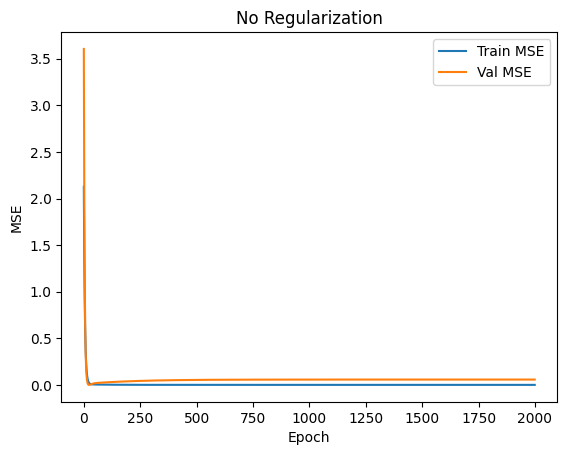

In [44]:
plt.plot(hist0["epoch"], hist0["train_MSE"], label="Train MSE")
plt.plot(hist0["epoch"], hist0["val_MSE"], label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("No Regularization")
plt.legend()
plt.show()


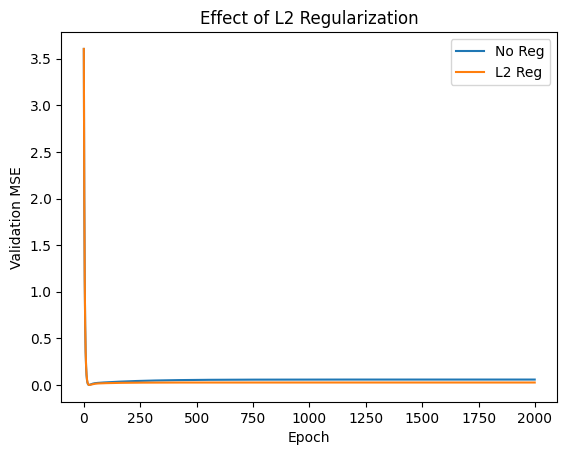

In [45]:
w_l2, b_l2, hist_l2 = train_gd(Xtr, ytr, Xv, yv, lr=0.05, epochs=2000, l2=0.05)

plt.plot(hist0["epoch"], hist0["val_MSE"], label="No Reg")
plt.plot(hist_l2["epoch"], hist_l2["val_MSE"], label="L2 Reg")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Effect of L2 Regularization")
plt.legend()
plt.show()


In [46]:
results = []

for lam in [0, 0.01, 0.05, 0.1, 0.2]:
    _, _, h = train_gd(Xtr, ytr, Xv, yv, lr=0.05, epochs=1500, l2=lam)
    results.append({"lambda": lam, "val_MSE": h.iloc[-1]["val_MSE"]})

pd.DataFrame(results)


,lambda,val_MSE
0,0.00,0.058
1,0.01,0.047
2,0.05,0.026
3,0.10,0.015
4,0.20,0.005


In [47]:
y_test_pred = predict(Xt, w_l2, b_l2)

test_result = test.copy()
test_result["prediction"] = y_test_pred
test_result["error"] = test_result["price_y"] - test_result["prediction"]

test_result


,x1_size,x2_bedrooms,price_y,prediction,error
6,7,4,2.5,2.671,-0.171
